# Quantum Tunneling Simulation Using the Crank-Nicolson Method

In [1]:
import numpy as np

import scipy.sparse as sp
import scipy.sparse.linalg as spla

import matplotlib.pyplot as plt
from matplotlib import animation

from tqdm import tqdm

## Introduction

Quantum mechanics provides a fundamental understanding of the behavior of particles at microscopic scales. One of the fascinating phenomena predicted by quantum mechanics is **quantum tunneling**, where a particle has a finite probability of crossing a potential barrier, even if its energy is less than the height of the barrier. This phenomenon has no classical counterpart and is crucial in many areas of physics, such as nuclear fusion in stars and the operation of diodes. In this project, a numerical simulation of quantum tunneling in one dimension is implemented using the **Crank-Nicolson method**, an implicit finite difference scheme. The simulation solves the time-dependent Schrödinger equation to model the behavior of a quantum wave packet encountering a potential barrier.

## Physical System

The system under consideration is a quantum particle of mass $m$ moving in one dimension. The particle is described by a wave function $\psi(x,t)$, which evolves over time according to the time-dependent Schrödinger equation (TDSE). The potential energy $ V(x) $ of the particle is specified as a barrier, allowing us to observe the tunneling effect.

### Time-Dependent Schrödinger Equation (TDSE)

The TDSE in one dimension is given by:

$$i\hbar \frac{\partial \psi(x,t)}{\partial t} = -\frac{\hbar^2}{2m} \frac{\partial^2 \psi(x,t)}{\partial x^2} + V(x) \psi(x,t)$$

For simplicity, dimensionless units are used where $ \hbar = 1 $ and $ m = 1 $, reducing the equation to:

$$i \frac{\partial \psi(x,t)}{\partial t} = -\frac{1}{2} \frac{\partial^2 \psi(x,t)}{\partial x^2} + V(x) \psi(x,t)$$

### Potential Barrier

The potential $ V(x) $ in this simulation is defined as a rectangular barrier placed between $x=0$ and $x=L$. The height $V_0$ and width $L$ of the barrier are parameters that can be adjusted.

$$
V(x) = \begin{cases} 
V_0 & \text{if } 0\le x \le L \\
0 & \text{otherwise}
\end{cases}
$$

In [2]:
x, Δx = np.linspace(-30,30, 3000, retstep=True)

V0 = 1
L = 1
V = V0 * np.logical_and(0<=x, x<=(L))

### Initial Wave Packet

The initial state of the system is a Gaussian wave packet, characterized by its initial position $ \mu $, width $ \sigma $, and momentum $ k_0 $:

$$\psi(x,0) = A\exp\left( -\frac{(x - \mu)^2}{2\sigma^2} \right) \exp(ik_0x)$$

The coefficient $A$ is choosen such that the total probability of the wave function is normalized .

$$\int |\psi(x,0)|^2 dx = 1$$

In [3]:
def initialize_wave_packet(k0, μ, σ):
        ψ = np.exp(1j * k0 * x) * np.exp(-(x - μ) ** 2 / (2 * σ ** 2))
        return normalize(ψ)

def normalize(ψ):
    norm = np.sum(np.abs(ψ) ** 2) * Δx
    return ψ / np.sqrt(norm)

ψ0 = initialize_wave_packet(k0=5, μ=-5, σ=1)

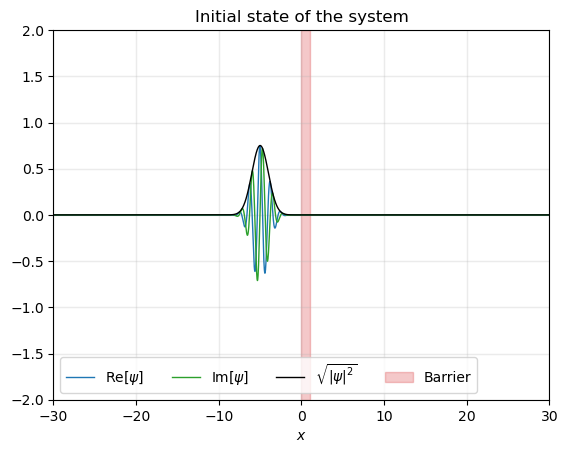

In [4]:
real = np.real(ψ0)
imag = np.imag(ψ0)
prob = np.abs(ψ0)

fig, ax = plt.subplots()

ax.plot(x, real, label='Re$[\psi]$', c='C0', lw=1, alpha=1, ls='-')
ax.plot(x, imag, label='Im$[\psi]$', c='C2', lw=1, alpha=1, ls='-')
ax.plot(x, prob, label='$\sqrt{|\psi|^2}$', c='k', lw=1, alpha=1)

ax.axvspan(0, L, alpha=0.25, color='C3', label='Barrier')

ax.set(xlim = (-30,30), ylim=(-2,2), xlabel='$x$')

ax.grid(lw=1, alpha=0.25)
ax.legend(loc='lower left', ncol=4)
ax.set_title('Initial state of the system');

## Numerical Method: Crank-Nicolson Scheme

**Crank-Nicolson method** is used to simulate the time evolution of the wave function, a popular finite difference scheme for solving partial differential equations like the TDSE. The Crank-Nicolson method is an implicit method, meaning it involves solving a system of linear equations at each time step, which enhances stability and accuracy compared to explicit methods.

### Discretization

The spatial domain is discretized into a grid with points $ x_j $ separated by a distance $ \Delta x $. The time is also discretized into steps of size $ \Delta t $. The wave function $ \psi(x,t) $ is approximated on this grid.

The Crank-Nicolson method approximates the TDSE by averaging the finite difference approximation of the spatial derivative between time steps $ n $ and $ n+1 $:

$$
\frac{\psi_j^{n+1} - \psi_j^n}{\Delta t} = \frac{1}{2} \left( H \psi_j^n + H \psi_j^{n+1} \right)
$$

where $ H $ is the Hamiltonian operator. This equation can be rearranged into a form that requires solving a tridiagonal system of linear equations:

$$
\left( I + \frac{i \Delta t}{2} H \right) \psi^{n+1} = \left( I - \frac{i \Delta t}{2} H \right) \psi^n
$$

Here, $ I $ is the identity matrix, and $ H $ is the discretized Hamiltonian matrix.

### Hamiltonian Matrix Construction

The Hamiltonian matrix $ H $ is constructed using a central difference approximation for the second derivative:

$$
\frac{d^2 \psi_j}{dx^2} \approx \frac{\psi_{j+1} - 2\psi_j + \psi_{j-1}}{\Delta x^2}
$$

Thus, the Hamiltonian matrix $ H $ is a tridiagonal matrix with elements depending on the potential $ V(x_j) $ and the grid spacing $ \Delta x $.

Given that the Hamiltonian for the kinetic energy term in the Schrödinger equation is:

$$
H = -\frac{1}{2} \frac{d^2}{dx^2} + V(x)
$$

And using the central difference approximation for the second derivative:

$$
\frac{d^2 \psi_j}{dx^2} \approx \frac{\psi_{j+1} - 2\psi_j + \psi_{j-1}}{\Delta x^2}
$$

The Hamiltonian matrix $ H $ becomes a tridiagonal matrix with elements that represent the discretized version of the kinetic and potential energy terms. Let's consider a small grid with 5 points for simplicity.

### Example Hamiltonian Matrix $ H $ for 5 Grid Points

Assume grid points $ x_1, x_2, x_3, x_4, x_5 $, and corresponding wave function values $ \psi_1, \psi_2, \psi_3, \psi_4, \psi_5 $.

Using the central difference approximation the Hamiltonian matrix $ H $ for these points becomes:

$$
H = -\frac{1}{2\Delta x^2}
\begin{pmatrix}
-2 & 1 & 0 & 0 & 0 \\
1 & -2 & 1 & 0 & 0 \\
0 & 1 & -2 & 1 & 0 \\
0 & 0 & 1 & -2 & 1 \\
0 & 0 & 0 & 1 & -2
\end{pmatrix}
+ \begin{pmatrix}
V_1 & 0 & 0 & 0 & 0 \\
0 & V_2 & 0 & 0 & 0 \\
0 & 0 & V_3 & 0 & 0 \\
0 & 0 & 0 & V_4 & 0 \\
0 & 0 & 0 & 0 & V_5
\end{pmatrix}
$$

Diagonal Elements $ \left( \frac{2}{\Delta x^2} + V_j \right) $  represent the contributions from the kinetic energy ($ -2 $ in the tridiagonal matrix) and the potential energy ($ V_j $) at each grid point. Off-Diagonal Elements $ \left( -\frac{1}{\Delta x^2} \right) $ represent the coupling between neighboring grid points due to the second derivative.

For a general grid with $ M $ points, the Hamiltonian matrix $ H $ would be an $ M \times M $ tridiagonal matrix where the diagonal elements include both kinetic and potential energy terms, and the off-diagonal elements represent the kinetic coupling between adjacent points.

This tridiagonal structure is characteristic of finite difference discretizations and makes the Crank-Nicolson method efficient for solving the resulting linear systems.


In [5]:
off_diags = -0.5 / Δx**2 * np.ones(x.size - 1)
diags = np.diag(2 * 0.5 / Δx**2 + V)
diags_off1 = np.diag(off_diags, k=1)
diags_off2 = np.diag(off_diags, k=-1)

H = diags + diags_off1 + diags_off2

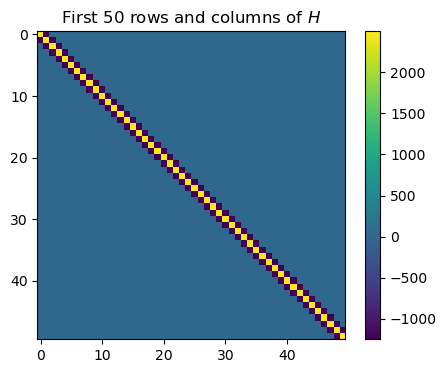

In [6]:
fig, ax = plt.subplots(figsize=(5,4))

im = ax.imshow(H[:,:50][:50,:])
plt.colorbar(im)
ax.set_title('First 50 rows and columns of $H$');

### Simulation Procedure

The simulation proceeds by initializing the wave packet and then iterating over time steps using the Crank-Nicolson scheme. At each step, the wave function is updated by solving the tridiagonal system of equations, yielding the wave function at the next time step. All of this is put together in the ```CrankNicolson``` class below.

In [7]:
class CrankNicolson:
    def __init__(self, xlim=(-10, 10), num_points=1000, Δt=0.01, t_final=1.0, xlim_plot=(-1,3), V0=None, L=None):
        self.x, self.Δx = np.linspace(*xlim, num_points, retstep=True)
        self.Δt = Δt
        self.t_final = t_final
        self.num_sim_steps = int(t_final / Δt)
    
        self.V0, self.L = V0, L
        self.V = np.logical_and(0<=self.x, self.x<=(L)) * V0
        
        self.xlim_plot = xlim_plot
        self.idx_plot =  np.logical_and(self.x>=self.xlim_plot[0], self.x<=self.xlim_plot[1])
        
        # Construct the Hamiltonian
        self.H = self.construct_hamiltonian()
        
        # Construct the left handside and right handside matrices for Crank-Nicolson
        self.LHS, self.RHS = self.construct_crank_nicolson_matrices()

    def construct_hamiltonian(self):
        # Discretized second derivative (Laplacian) using finite differences
        off_diags = -0.5 / self.Δx**2 * np.ones(self.x.size - 1)
        diags = np.diag(2 * 0.5 / self.Δx**2 + self.V)
        diags_off1 = np.diag(off_diags, k=1)
        diags_off2 = np.diag(off_diags, k=-1)
        
        H = diags + diags_off1 + diags_off2
        return sp.csr_matrix(H)

    def construct_crank_nicolson_matrices(self):
        I = sp.eye(self.x.size, format='csr')
        A = I + 1j * self.Δt / 2 * self.H
        B = I - 1j * self.Δt / 2 * self.H
        
        return A, B

    def initialize_wave_packet(self, k0, μ, σ):
        self.k0 = k0
        self.μ = μ
        self.σ = σ
        ψ = np.exp(1j * k0 * self.x) * np.exp(-(self.x - μ) ** 2 / (2 * σ ** 2))
        return self.normalize(ψ)

    def normalize(self, ψ):
        norm = np.sum(np.abs(ψ) ** 2) * self.Δx
        return ψ / np.sqrt(norm)

    def simulate(self, ψ0):
        ψ = ψ0
        trajectory = []
        
        for _ in tqdm(range(self.num_sim_steps)):
            b = self.RHS.dot(ψ)
            ψ = spla.spsolve(self.LHS, b)
            trajectory.append(np.copy(ψ))
        
        self.trajectory = np.array(trajectory) 
        #np.savez(f'trajectory_k0_{self.k0}_V0_{self.V0}.npz', trajectory=trajectory)

    def plot_ψ(self, ψ):
        
        x = self.x

        real = np.real(ψ)
        imag = np.imag(ψ)
        prob = np.abs(ψ)

        real_line, *_ = plt.plot(x, real, label='Re$[\psi]$', c='C0', lw=1, alpha=1, ls='-')
        imag_line, *_ = plt.plot(x, imag, label='Im$[\psi]$', c='C2', lw=1, alpha=1, ls='-')
        prob_line, *_ = plt.plot(x, prob, label='$\sqrt{|\psi|^2}$', c='k', lw=1, alpha=1)

        if self.L is not None:
            plt.axvspan(0, self.L, alpha=0.25, color='C3', label='Barrier')

        plt.xlim(*self.xlim_plot)
        plt.ylim(-2,2)

        plt.grid(lw=1, alpha=0.25)
        plt.xlabel('$x$')
        plt.legend(loc='lower left', ncol=4)

        return prob_line, real_line, imag_line
    
    def animate(self, plot_every=1):

        x = self.x[self.idx_plot]
        traj = self.trajectory[::plot_every,self.idx_plot]

        prob = np.abs(traj)
        real = np.real(traj)
        imag = np.imag(traj)

        fig, ax = plt.subplots(dpi=200)
        prob_line, real_line, imag_line = self.plot_ψ(self.trajectory[0])
        ax.set_xlim(*self.xlim_plot)
        
        def animate(frame):
            prob_line.set_data(x, prob[frame])
            real_line.set_data(x, real[frame])
            imag_line.set_data(x, imag[frame])
            return prob_line, real_line, imag_line
        
        print('Generating animation')
        anim = animation.FuncAnimation(fig, animate, interval=1e-1, blit=True, repeat=True, frames=len(traj))
        anim.save(f'anim_k0_{self.k0}_V0_{self.V0}.gif', writer=animation.PillowWriter(fps=60))
        print('Done.')

## Numerical experiment

In the dimensionless units, kinetic energy of the wave packet is $T=\frac{k_0^2}{2}$. The height of the barrier is $V_0$.
Perform three simulations for $V_0 = [T/2, T, 2T]$ to demonstrate quantum tunelling. For $k_0=5$, this corresponds to:

Solving for V0 = 6.25


100%|██████████████████████████████████████| 5000/5000 [00:14<00:00, 340.27it/s]


Generating animation
Done.
Solving for V0 = 12.5


100%|██████████████████████████████████████| 5000/5000 [00:12<00:00, 400.16it/s]


Generating animation
Done.
Solving for V0 = 25


100%|██████████████████████████████████████| 5000/5000 [00:07<00:00, 664.21it/s]


Generating animation
Done.


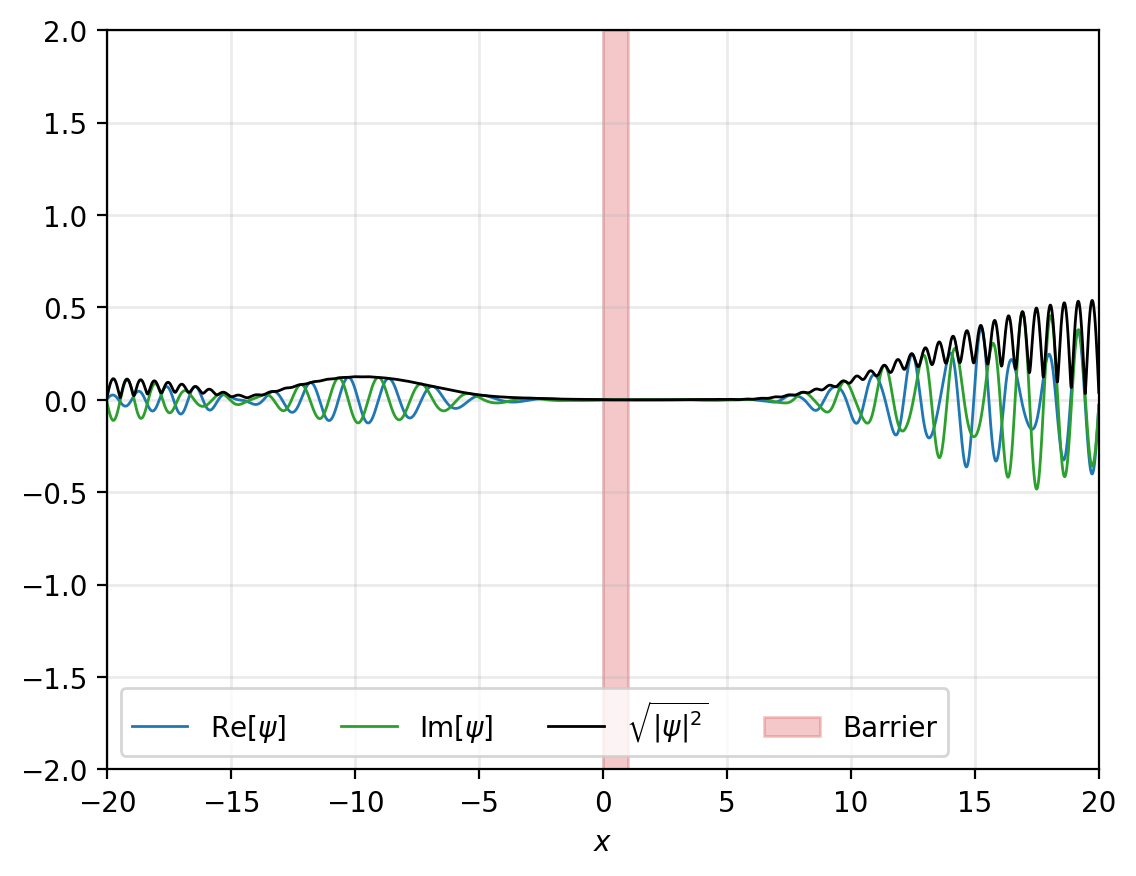

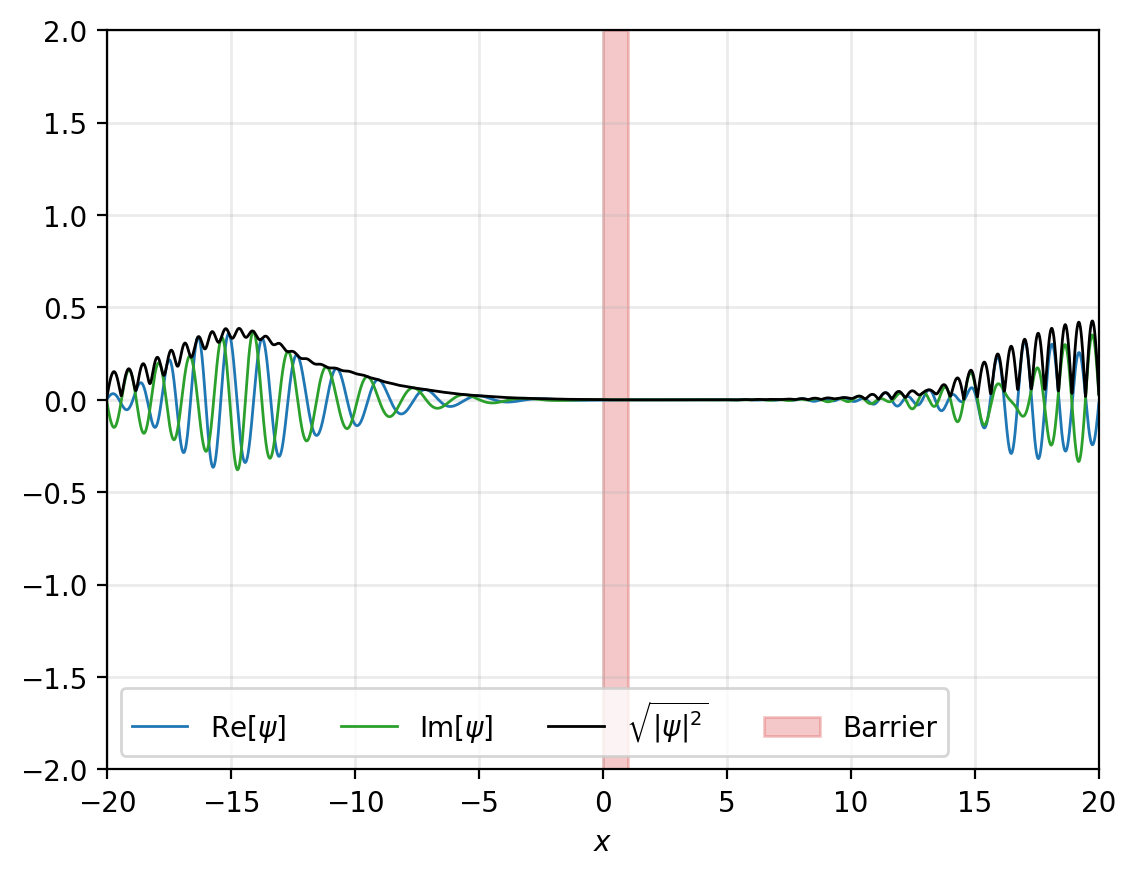

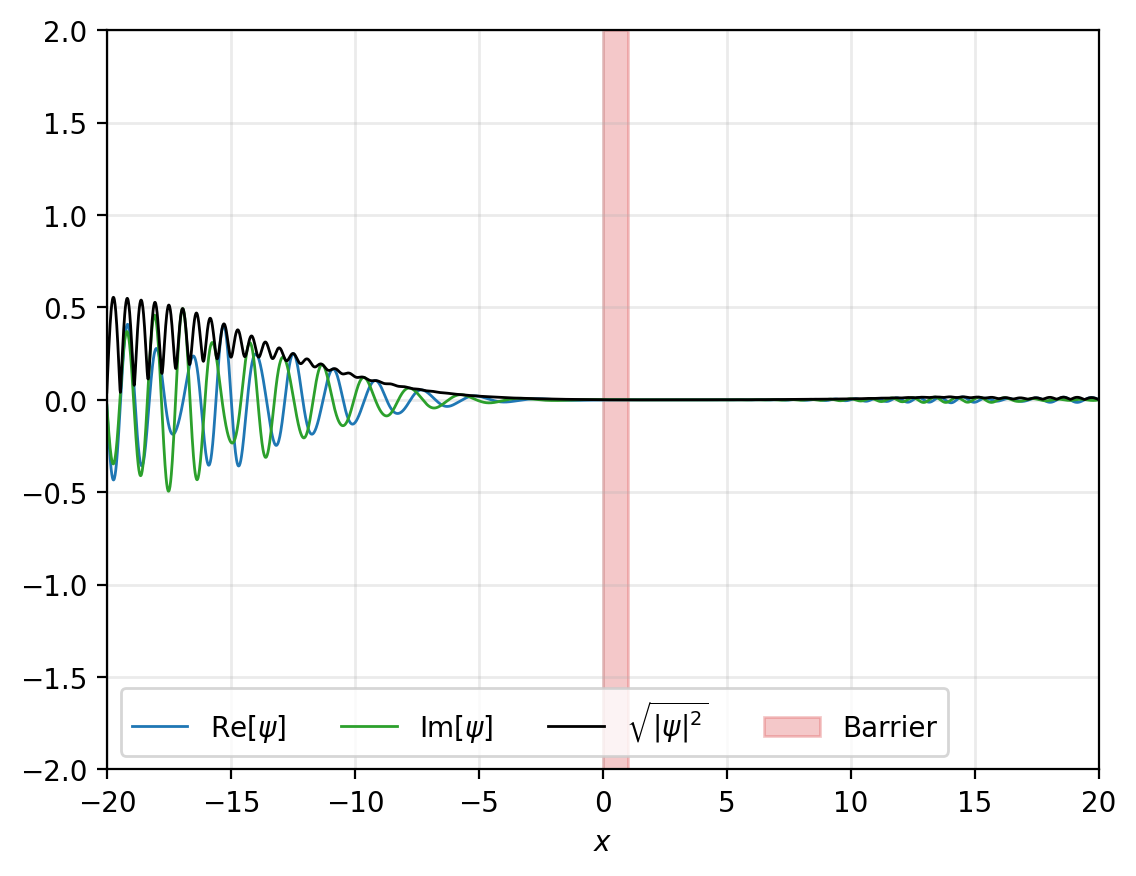

In [8]:
V0_list = [6.25, 12.5, 25]

for V0 in V0_list:
    print(f'Solving for {V0 = }')
    system = CrankNicolson(xlim=(-20, 20), num_points=3000, Δt=0.001, t_final=5.0, xlim_plot=(-20,20), V0=V0, L=1)
    ψ0 = system.initialize_wave_packet(k0=5, μ=-7.5, σ=1.0)
    system.simulate(ψ0)
    _ = system.animate(plot_every=40);

|   $V_0 = 6.25 $     |   $V_0 = 12.5$ |   $V_0 = 25$  |
|------------|-----------------|---------------|
| ![SegmentLocal](anim_k0_5_V0_6.25.gif "segment") | ![SegmentLocal](anim_k0_5_V0_12.5.gif "segment") | ![SegmentLocal](anim_k0_5_V0_25.gif "segment") |

In all simulations, at least a portion of the wave packet pass through the potential barrier. Even when the kinetic energy of the package is less than the height of the potential barrier. Quantum tunneling is clearly visible in all animations of these simulations. Notice that the transmitted portion of the wave packet is moving faster than the reflected portion in all simulations. A quantum wave packet is made up of many components, each with different energies. When this wave packet hits a potential barrier, the higher energy, faster components of the wave are more likely to pass through, while the lower energy, slower components tend to get reflected. This happens because the higher energy components have enough momentum to overcome or tunnel through the barrier, but the lower energy components don't have enough energy and bounce back instead. So, the transmitted wave, which mostly has the higher energy components, ends up moving faster than the reflected wave, which mainly has the lower energy components that couldn't get through the barrier.

### Transmission probability

In order to calculate the transmission probability, we need to integrate the the probability density that is on the right hand side of the barrier. 

$$P_T = \int_L^{20}|\psi(x)|^2 dx$$

In [9]:
V0_list = np.linspace(0,40,10)
P_T_list = np.zeros((len(V0_list),5000))

for i, V0 in enumerate(V0_list):
    print(f'{i}: Solving for {V0 = }')
    system = CrankNicolson(xlim=(-20, 20), num_points=3000, Δt=0.001, t_final=5.0, xlim_plot=(-20,20), V0=V0, L=1)
    ψ0 = system.initialize_wave_packet(k0=5, μ=-7.5, σ=1.0)
    system.simulate(ψ0)
    P_T_list[i] = np.square(abs(system.trajectory[:,system.x>system.L])).sum(axis=1) * system.Δx
del system

0: Solving for V0 = 0.0


100%|██████████████████████████████████████| 5000/5000 [00:06<00:00, 720.98it/s]


1: Solving for V0 = 4.444444444444445


100%|██████████████████████████████████████| 5000/5000 [00:05<00:00, 843.74it/s]


2: Solving for V0 = 8.88888888888889


...

100%|██████████████████████████████████████| 5000/5000 [00:06<00:00, 754.32it/s]


8: Solving for V0 = 35.55555555555556


100%|██████████████████████████████████████| 5000/5000 [00:07<00:00, 685.83it/s]


9: Solving for V0 = 40.0


100%|██████████████████████████████████████| 5000/5000 [00:05<00:00, 854.16it/s]


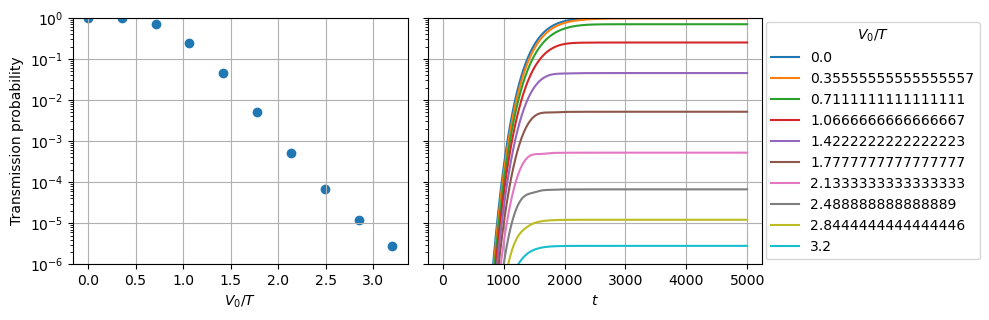

In [10]:
fig, ax = plt.subplots(1,2,figsize=(10,3.3), sharey=True)

ax[0].scatter(V0_list/12.5, P_T_list[:,-1])
ax[0].set(yscale='log', xlabel='$V_0/T$', ylabel='Transmission probability')
ax[0].grid()

ax[1].plot(P_T_list.T, label=V0_list/12.5)
ax[1].set(yscale='log', xlabel='$t$',ylim=(1e-6,1e0))
ax[1].grid()
ax[1].legend(loc=(1.01,0.02), title='$V_0/T$')
fig.tight_layout()

The first figure shows a clear exponential relationship between the transmission probability and the barrier height but only when the barier height is larger than the kinetic energy of the wave packet ($V_0/T>1$). Second figure shows the convergence times of the transmission probabilities troughout the simulation for each barrier height. Notice the non-zero transmission probability even when the barrier height is 3.2 times of the kinetic energy of the wave packet.

## Summary

In this project, a quantum tunneling system was simulated, where a wave packet interacts with a potential barrier. The time-dependent Schrödinger equation governing this system was solved numerically to study the behavior of the wave packet as it encounters the barrier.

The Crank-Nicolson method, an implicit finite difference scheme, was employed to solve the Schrödinger equation. The Hamiltonian matrix was constructed using a central difference approximation for the kinetic energy term, and the potential energy was incorporated to model the barrier. This method was chosen for its stability and accuracy in handling quantum mechanical problems.

Experiments were conducted by simulating the evolution of the wave packet as it approached, interacted with, and either tunneled through or reflected off the potential barrier of different heights. The simulation revealed that higher energy components of the wave packet were more likely to tunnel through the barrier, resulting in a transmitted wave that appeared faster than the reflected wave. The lower energy components, lacking sufficient energy to overcome the barrier, were primarily reflected. It is observed that regardless of the height of the potential barrier, there is always a non-zero probability of transmission.

